# 4. Evaluación composicional tipo Winoground



## Qué mide Winoground que R@1 no puede ver

En un montaje contrastivo, los dos captions comparten vocabulario y solo
difieren en la **relación** que describen. El título deja de servir: para
acertar hay que leer el gráfico.

Siguiendo el Cuaderno 15, cada caso son dos imágenes y dos captions, con una
matriz de similitud 2×2, y tres señales:

| Señal | Qué exige |
|---|---|
| **text score** | cada caption prefiere su imagen correcta |
| **image score** | cada imagen prefiere su caption correcto |
| **group score** | ambas condiciones a la vez |

El group score es deliberadamente estricto: un modelo que acierta por azar en
una dirección casi nunca acierta en las dos.

## Hipótesis

La del Cuaderno 15, aplicada a este dominio: un modelo contrastivo puede
capturar correspondencias globales imagen-texto y aun así fallar cuando la
respuesta exige composición fina. Si se confirma, explica por qué los captions
largos nunca pudieron ganar.

## 4.1 Configuración

Se registran los once puntos de reproducibilidad que exige el Cuaderno 15:
modelo, checkpoint, dataset, número de ejemplos, semilla, librerías, hardware,
parámetros de inferencia, predicciones crudas, métricas y matriz de errores.

In [1]:
import json
import platform
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MULTI = BASE / "multiedicion"
# --- variante de imágenes -------------------------------------------------
# Un único punto decide si se trabaja con las imágenes que llevan el título
# impreso o con las recortadas. El manifiesto es el mismo para ambas; cambia
# solo la subcarpeta. El nombre del directorio de salida arrastra la variante,
# de modo que dos corridas nunca se sobrescriben.
import sys
sys.path.insert(0, str(BASE))
from config_variante import (VARIANTE, carpeta_imagenes, ruta_imagen,
                             dir_salida, resumen)

IMGS = carpeta_imagenes(MULTI)
print(resumen(MULTI))

OUT = dir_salida(BASE, "resultados_winoground")

SEED = 22514                      # misma semilla del Cuaderno14
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_SPECS = {
    "CLIP":     {"checkpoint": "openai/clip-vit-base-patch32",
                 "max_tokens": 77,  "encoder_visual": "ViT-B/32", "patch": 32},
    "CLIP-L":   {"checkpoint": "openai/clip-vit-large-patch14",
                 "max_tokens": 77,  "encoder_visual": "ViT-L/14", "patch": 14},
    "LongCLIP": {"checkpoint": "zer0int/LongCLIP-GmP-ViT-L-14",
                 "max_tokens": 248, "encoder_visual": "ViT-L/14", "patch": 14},
}

# Dos conjuntos disponibles:
#   winoground_pares.jsonl            12 pares construidos a mano; los captions
#                                     difieren en tema además de en relación
#   winoground_pares_estrictos.jsonl  40 pares con vocabulario IDÉNTICO entre
#                                     las dos opciones: solo cambia la asignación
#                                     de cada término a su rol
DATASET = "winoground_pares_estrictos.jsonl"
#DATASET = "winoground_pares.jsonl"
# --- variante de imágenes -------------------------------------------------
# Un único punto decide si se trabaja con las imágenes que llevan el título
# impreso o con las recortadas. El manifiesto es el mismo para ambas; cambia
# solo la subcarpeta. El nombre del directorio de salida arrastra la variante,
# de modo que dos corridas nunca se sobrescriben.
import sys
sys.path.insert(0, str(BASE))
from config_variante import (VARIANTE, carpeta_imagenes, ruta_imagen,
                             dir_salida, resumen)

IMGS = carpeta_imagenes(MULTI)
print(resumen(MULTI))

OUT = dir_salida(BASE, f"resultados_winoground_{Path(DATASET).stem.split('_')[-1]}")

pares = [json.loads(l) for l in open(BASE / "notebooks" / DATASET, encoding="utf-8")]
print(f"{len(pares)} pares contrastivos ({DATASET})")

# verificación: en el conjunto estricto ambos captions deben usar las mismas
# palabras, o el par no mide composición sino coincidencia léxica
import re, unicodedata
def _palabras(t):
    t = unicodedata.normalize("NFD", t.lower())
    t = "".join(c for c in t if unicodedata.category(c) != "Mn")
    return sorted(re.findall(r"\w+", t))

if pares[0].get("estricto"):
    malos = [p["pair_id"] for p in pares
             if _palabras(p["caption_a"]) != _palabras(p["caption_b"])]
    assert not malos, f"pares con vocabulario distinto: {malos}"
    print("verificado: vocabulario idéntico en los dos captions de cada par")
print(f"dispositivo: {DEVICE} | torch {torch.__version__}")
pd.Series([p["fenomeno"] for p in pares]).value_counts().to_frame("n")

variante: con_titulo | carpeta: con_titulo | 95 imágenes
variante: con_titulo | carpeta: con_titulo | 95 imágenes
40 pares contrastivos (winoground_pares_estrictos.jsonl)
verificado: vocabulario idéntico en los dos captions de cada par
dispositivo: cuda | torch 2.5.1+cu121


,n
rol_principal,10
foco_vs_referencia,10
presencia_ausencia,10
orden_de_mencion,10


## 4.2 Verificación del dataset

Antes de medir, comprobar que las imágenes existen y que ningún par usa la misma
imagen dos veces: eso haría la matriz degenerada y el resultado no significaría
nada.

In [2]:
problemas = []
for p in pares:
    for k in ("image_a", "image_b"):
        if not Path(ruta_imagen(MULTI, p[k])).exists():
            problemas.append(f"{p['pair_id']}: falta {p[k]}")
    if p["image_a"] == p["image_b"]:
        problemas.append(f"{p['pair_id']}: misma imagen en ambos lados")
    if p["caption_a"].strip() == p["caption_b"].strip():
        problemas.append(f"{p['pair_id']}: captions idénticos")

print("problemas:", problemas if problemas else "ninguno")
print(f"imágenes distintas usadas: "
      f"{len({p[k] for p in pares for k in ('image_a', 'image_b')})}")

problemas: ninguno
imágenes distintas usadas: 37


## 4.3 Los tres scores

Implementación literal del Cuaderno 15. La matriz es 2×2 con las imágenes en las
filas y los captions en las columnas, de modo que la diagonal contiene los pares
correctos.

- **image score** compara dentro de cada fila: la imagen elige entre los dos captions
- **text score** compara dentro de cada columna: el caption elige entre las dos imágenes

Son criterios distintos y pueden diferir. Que un caption identifique su imagen no
implica que la imagen identifique ese caption.

In [3]:
def compute_winoground_scores(similarity_2x2):
    matrix = np.asarray(similarity_2x2, dtype=float)

    image_score = int(matrix[0, 0] > matrix[0, 1] and matrix[1, 1] > matrix[1, 0])
    text_score = int(matrix[0, 0] > matrix[1, 0] and matrix[1, 1] > matrix[0, 1])
    group_score = int(image_score == 1 and text_score == 1)

    return {
        "image_score": image_score,
        "text_score": text_score,
        "group_score": group_score,
        "s00": float(matrix[0, 0]), "s01": float(matrix[0, 1]),
        "s10": float(matrix[1, 0]), "s11": float(matrix[1, 1]),
    }


# verificación con matrices construidas a mano
perfecta = [[0.9, 0.1], [0.1, 0.9]]      # diagonal domina: todo correcto
invertida = [[0.1, 0.9], [0.9, 0.1]]     # antidiagonal: todo incorrecto
parcial = [[0.9, 0.1], [0.8, 0.7]]       # texto acierta, imagen no

for nombre, mm in [("perfecta", perfecta), ("invertida", invertida), ("parcial", parcial)]:
    s = compute_winoground_scores(mm)
    print(f"{nombre:10s} image={s['image_score']} text={s['text_score']} "
          f"group={s['group_score']}")

perfecta   image=1 text=1 group=1
invertida  image=0 text=0 group=0
parcial    image=0 text=1 group=0


### Niveles de azar

Un modelo que responde al azar acierta la mitad de las veces en cada dirección.
El group score exige las dos a la vez, así que su azar es 0.25.

Esta referencia es la que da sentido al resultado: un group score de 0.30 con
doce pares **no es evidencia de composicionalidad**, es ruido alrededor del azar.

In [4]:
import math
n = len(pares)
se = math.sqrt(0.25 * 0.75 / n)
print("azar esperado:  image=0.50   text=0.50   group=0.25")
print(f"pares evaluados: {n}")
print(f"un acierto adicional mueve el score en {1/n:.3f}")
print(f"IC95 alrededor del azar: [{max(0, 0.25-1.96*se):.3f}, {min(1, 0.25+1.96*se):.3f}]")
print("\nCuanto más estrecho sea ese intervalo, más capaz es la prueba de")
print("detectar una diferencia real respecto del azar.")

azar esperado:  image=0.50   text=0.50   group=0.25
pares evaluados: 40
un acierto adicional mueve el score en 0.025
IC95 alrededor del azar: [0.116, 0.384]

Cuanto más estrecho sea ese intervalo, más capaz es la prueba de
detectar una diferencia real respecto del azar.


## 4.4 Carga de modelos

Idéntica al notebook 03. Para LongCLIP hay que ampliar `max_position_embeddings`
a 248 **antes** de cargar los pesos; de lo contrario el modelo se instancia con
las 77 posiciones de CLIP y la ventana larga nunca se usa.

In [5]:
from transformers import CLIPModel, CLIPProcessor, CLIPConfig

def cargar_modelo(nombre):
    spec = MODEL_SPECS[nombre]
    ck, maxlen = spec["checkpoint"], spec["max_tokens"]

    if maxlen > 77:
        cfg = CLIPConfig.from_pretrained(ck)
        cfg.text_config.max_position_embeddings = maxlen
        modelo = CLIPModel.from_pretrained(ck, config=cfg, use_safetensors=True)
    else:
        modelo = CLIPModel.from_pretrained(ck, use_safetensors=True)

    proc = CLIPProcessor.from_pretrained(ck)
    modelo = modelo.to(DEVICE).eval()

    real = modelo.config.text_config.max_position_embeddings
    assert real == maxlen, f"{nombre}: se esperaban {maxlen} posiciones, hay {real}"
    print(f"  {nombre}: {real} posiciones de texto")
    return modelo, proc


@torch.no_grad()
def matriz_2x2(modelo, proc, ruta_a, ruta_b, cap_a, cap_b, maxlen):
    """Similitud coseno entre las dos imágenes y los dos captions."""
    imgs = [Image.open(ruta_imagen(MULTI, r)).convert("RGB") for r in (ruta_a, ruta_b)]
    ei = modelo.get_image_features(**proc(images=imgs, return_tensors="pt").to(DEVICE))
    ei = torch.nn.functional.normalize(ei, dim=-1)

    inp = proc(text=[cap_a, cap_b], return_tensors="pt", padding=True,
               truncation=True, max_length=maxlen).to(DEVICE)
    et = modelo.get_text_features(**inp)
    et = torch.nn.functional.normalize(et, dim=-1)

    return (ei @ et.T).cpu().numpy()

/tf/work/torch_gpu_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4.5 Corrida

Cada par se evalúa con los tres modelos. Se guardan las similitudes crudas, no
solo los aciertos: sin ellas no se puede auditar el resultado ni distinguir un
fallo rotundo de uno por diferencia mínima.

In [6]:
filas = []

for nombre in MODEL_SPECS:
    print(f"\n--- {nombre} ---")
    modelo, proc = cargar_modelo(nombre)
    maxlen = MODEL_SPECS[nombre]["max_tokens"]

    for p in pares:
        sim = matriz_2x2(modelo, proc, p["image_a"], p["image_b"],
                         p["caption_a"], p["caption_b"], maxlen)
        s = compute_winoground_scores(sim)
        filas.append({"pair_id": p["pair_id"], "modelo": nombre,
                      "fenomeno": p["fenomeno"],
                      "chart_a": p["chart_a"], "chart_b": p["chart_b"], **s})

    del modelo
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

pred = pd.DataFrame(filas)
pred.to_csv(OUT / "predicciones_crudas.csv", index=False)
print(f"\n{len(pred)} evaluaciones ({len(pares)} pares x {len(MODEL_SPECS)} modelos)")


--- CLIP ---


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


  CLIP: 77 posiciones de texto

--- CLIP-L ---
  CLIP-L: 77 posiciones de texto

--- LongCLIP ---
  LongCLIP: 248 posiciones de texto

120 evaluaciones (40 pares x 3 modelos)


## 4.6 Resultado principal

In [7]:
resumen = (pred.groupby("modelo")[["image_score", "text_score", "group_score"]]
               .mean().round(3)
               .reindex(list(MODEL_SPECS)))
resumen["n_pares"] = len(pares)
resumen.to_csv(OUT / "scores_por_modelo.csv")

print(resumen.to_string())
print("\nazar:  image=0.500  text=0.500  group=0.250")

sobre_azar = resumen["group_score"] > 0.25
print("\nmodelos por encima del azar en group score:",
      list(resumen.index[sobre_azar]) or "ninguno")

          image_score  text_score  group_score  n_pares
modelo                                                 
CLIP            0.225       0.175        0.125       40
CLIP-L          0.300       0.175        0.075       40
LongCLIP        0.550       0.250        0.175       40

azar:  image=0.500  text=0.500  group=0.250

modelos por encima del azar en group score: ninguno


## 4.7 Desagregación por fenómeno

El Cuaderno 15 lo dice explícitamente: *un promedio bajo no basta, se debe
inspeccionar qué tipo de fenómeno produce el fallo*.

Con doce pares cada celda tiene uno o dos casos, así que esto es **exploratorio,
no concluyente**. Sirve para orientar dónde mirar, no para afirmar diferencias
entre fenómenos.

In [8]:
por_fen = (pred.pivot_table(index="fenomeno", columns="modelo",
                            values="group_score", aggfunc="mean")
              .reindex(columns=list(MODEL_SPECS))
              .round(2))
por_fen["n"] = pred.groupby("fenomeno")["pair_id"].nunique()
por_fen.to_csv(OUT / "scores_por_fenomeno.csv")
print(por_fen.to_string())

modelo              CLIP  CLIP-L  LongCLIP   n
fenomeno                                      
foco_vs_referencia   0.0     0.0       0.1  10
orden_de_mencion     0.0     0.0       0.1  10
presencia_ausencia   0.1     0.2       0.2  10
rol_principal        0.4     0.1       0.3  10


## 4.8 Márgenes: qué tan lejos estuvo el modelo

Los scores son binarios y esconden la magnitud. El margen mide **cuánto** ganó
la respuesta correcta:

```
margen = similitud(par correcto) - similitud(par incorrecto)
```

Un margen positivo pero minúsculo es un acierto frágil: con otra semilla o un
recorte ligeramente distinto se habría perdido. Un margen negativo grande indica
que el modelo está seguro de la respuesta equivocada.

Esta es también la métrica que puede detectar el aporte de un caption largo
cuando no alcanza para cambiar el ranking.

In [9]:
pred["margen_img_a"] = pred["s00"] - pred["s01"]
pred["margen_img_b"] = pred["s11"] - pred["s10"]
pred["margen_medio"] = (pred["margen_img_a"] + pred["margen_img_b"]) / 2

m = (pred.groupby("modelo")["margen_medio"]
         .agg(["mean", "std", "min", "max"]).round(4)
         .reindex(list(MODEL_SPECS)))
m.to_csv(OUT / "margenes.csv")
print(m.to_string())

frag = pred[(pred.margen_medio > 0) & (pred.margen_medio < 0.01)]
print(f"\naciertos frágiles (margen < 0.01): {len(frag)}")
if len(frag):
    print(frag[["pair_id", "modelo", "margen_medio", "group_score"]].to_string(index=False))

            mean     std     min     max
modelo                                  
CLIP      0.0034  0.0054 -0.0070  0.0168
CLIP-L    0.0075  0.0087 -0.0051  0.0280
LongCLIP  0.0131  0.0082  0.0022  0.0415

aciertos frágiles (margen < 0.01): 60
pair_id   modelo  margen_medio  group_score
    s01     CLIP      0.002702            0
    s03     CLIP      0.000774            0
    s05     CLIP      0.000702            0
    s07     CLIP      0.007778            0
    s08     CLIP      0.002956            0
    s09     CLIP      0.006787            1
    s10     CLIP      0.004252            0
    s14     CLIP      0.003791            0
    s15     CLIP      0.004754            0
    s16     CLIP      0.002491            0
    s18     CLIP      0.003148            0
    s19     CLIP      0.003660            0
    s23     CLIP      0.002277            0
    s24     CLIP      0.000495            0
    s26     CLIP      0.007026            0
    s27     CLIP      0.006790            0
    s28 

## 4.9 Matriz de errores

Categorías del Cuaderno 15. Se prellena automáticamente con los fallos y se deja
la columna de categoría para anotación manual: clasificar un error exige mirar la
imagen, no solo el número.

In [10]:
ERROR_CATEGORIES = [
    "error_perceptual", "error_espacial", "error_composicional",
    "error_ocr", "error_conocimiento", "error_grounding",
    "error_prompt", "error_evaluacion",
]
SEVERITY_LEVELS = ["baja", "media", "alta"]

fallos = pred[pred.group_score == 0].copy()
fallos["categoria_error"] = ""       # a completar mirando la imagen
fallos["severidad"] = ""
fallos["observacion"] = ""

cols = ["pair_id", "modelo", "fenomeno", "chart_a", "chart_b",
        "image_score", "text_score", "margen_medio",
        "categoria_error", "severidad", "observacion"]
fallos[cols].to_csv(OUT / "matriz_errores.csv", index=False)

print(f"fallos a clasificar: {len(fallos)} de {len(pred)}")
print(f"categorías disponibles: {ERROR_CATEGORIES}")
print(f"\nplantilla en {OUT / 'matriz_errores.csv'}")
fallos[["pair_id", "modelo", "fenomeno", "image_score",
        "text_score", "margen_medio"]].head(10)

fallos a clasificar: 105 de 120
categorías disponibles: ['error_perceptual', 'error_espacial', 'error_composicional', 'error_ocr', 'error_conocimiento', 'error_grounding', 'error_prompt', 'error_evaluacion']

plantilla en /tf/work/final/sbs_iesf_pares/resultados_winoground_estrictos_con_titulo/matriz_errores.csv


,pair_id,modelo,fenomeno,image_score,text_score,margen_medio
0,s01,CLIP,rol_principal,0,0,0.002702
1,s02,CLIP,foco_vs_referencia,0,0,0.012033
2,s03,CLIP,presencia_ausencia,0,0,0.000774
3,s04,CLIP,orden_de_mencion,0,0,-0.006968
4,s05,CLIP,rol_principal,0,0,0.000702
5,s06,CLIP,foco_vs_referencia,0,0,0.016817
6,s07,CLIP,presencia_ausencia,0,0,0.007778
7,s08,CLIP,orden_de_mencion,0,0,0.002956
9,s10,CLIP,foco_vs_referencia,0,0,0.004252
10,s11,CLIP,presencia_ausencia,0,0,-0.001676


## 4.10 Inspección visual de un fallo

Ver el caso concreto es lo que permite clasificar el error. Sin esto, la matriz
de la celda anterior se llena a ciegas.

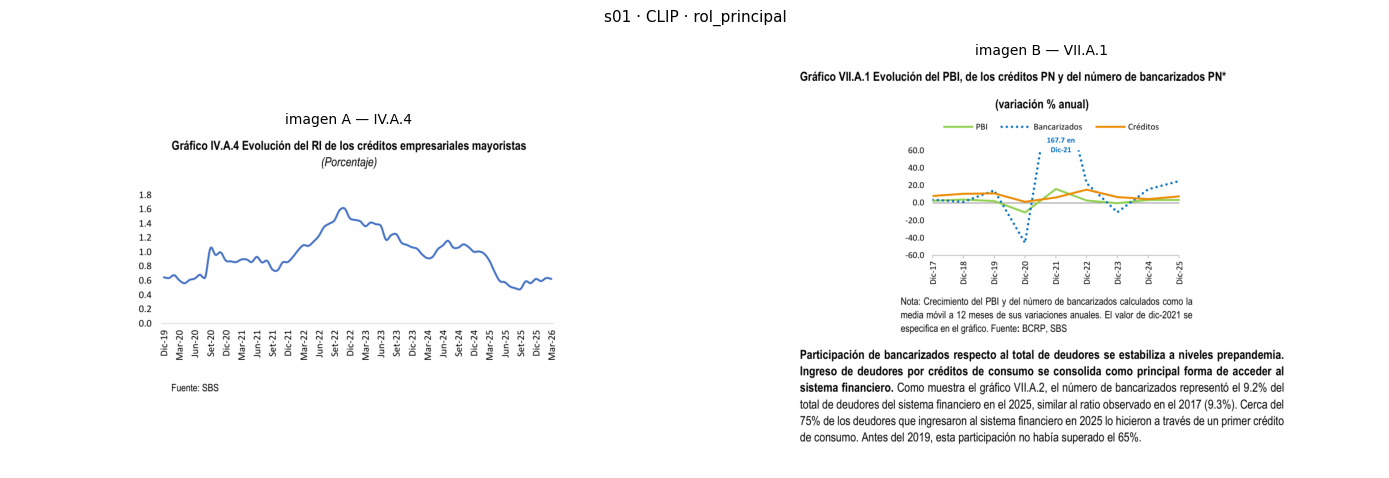

caption A: grafico de incumplimiento mayorista, no de bancarizados
caption B: grafico de bancarizados, no de incumplimiento mayorista

matriz: s00=0.2958 s01=0.2973 s10=0.3049 s11=0.3118
nota del dataset: intercambio de rol entre 'incumplimiento mayorista' y 'bancarizados'; ambos captions usan el mismo vocabulario


In [11]:
import matplotlib.pyplot as plt

if len(fallos):
    caso = fallos.iloc[0]
    p = next(x for x in pares if x["pair_id"] == caso.pair_id)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, lado in zip(axes, ("a", "b")):
        ax.imshow(Image.open(ruta_imagen(MULTI, p[f"image_{lado}"])))
        ax.set_title(f"imagen {lado.upper()} — {p[f'chart_{lado}']}", fontsize=10)
        ax.axis("off")
    plt.suptitle(f"{caso.pair_id} · {caso.modelo} · {caso.fenomeno}", fontsize=11)
    plt.tight_layout(); plt.show()

    print(f"caption A: {p['caption_a']}")
    print(f"caption B: {p['caption_b']}")
    print(f"\nmatriz: s00={caso.s00:.4f} s01={caso.s01:.4f} "
          f"s10={caso.s10:.4f} s11={caso.s11:.4f}")
    print(f"nota del dataset: {p['nota']}")
else:
    print("no hubo fallos que inspeccionar")

## 4.11 Configuración reproducible

Los once puntos del Cuaderno 15.

In [12]:
config = {
    "experiment": {
        "name": "proyecto2_evaluacion_composicional_iesf",
        "task": "emparejamiento_imagen_texto_contrastivo_2x2",
        "dataset": "winoground_pares.jsonl (gráficos IESF 2026-1)",
        "num_examples": len(pares),
        "seed": SEED,
        "metodologia": "Cuaderno 15, Semana 8 (MCC225)",
    },
    "models": MODEL_SPECS,
    "inference": {"normalizacion": "L2", "similitud": "coseno",
                  "padding": True, "truncation": True},
    "runtime": {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "torch": torch.__version__,
        "cuda_disponible": torch.cuda.is_available(),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    },
    "chance_levels": {"image_score": 0.5, "text_score": 0.5, "group_score": 0.25},
    "outputs": {
        "predicciones": "predicciones_crudas.csv",
        "scores": "scores_por_modelo.csv",
        "por_fenomeno": "scores_por_fenomeno.csv",
        "margenes": "margenes.csv",
        "errores": "matriz_errores.csv",
    },
}

with open(OUT / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)
print(json.dumps(config, ensure_ascii=False, indent=2)[:900], "...")

{
  "experiment": {
    "name": "proyecto2_evaluacion_composicional_iesf",
    "task": "emparejamiento_imagen_texto_contrastivo_2x2",
    "dataset": "winoground_pares.jsonl (gráficos IESF 2026-1)",
    "num_examples": 40,
    "seed": 22514,
    "metodologia": "Cuaderno 15, Semana 8 (MCC225)"
  },
  "models": {
    "CLIP": {
      "checkpoint": "openai/clip-vit-base-patch32",
      "max_tokens": 77,
      "encoder_visual": "ViT-B/32",
      "patch": 32
    },
    "CLIP-L": {
      "checkpoint": "openai/clip-vit-large-patch14",
      "max_tokens": 77,
      "encoder_visual": "ViT-L/14",
      "patch": 14
    },
    "LongCLIP": {
      "checkpoint": "zer0int/LongCLIP-GmP-ViT-L-14",
      "max_tokens": 248,
      "encoder_visual": "ViT-L/14",
      "patch": 14
    }
  },
  "inference": {
    "normalizacion": "L2",
    "similitud": "coseno",
    "padding": true,
    "truncation": true
  },
   ...


## 4.12 Cómo leer el resultado

| Group score observado | Qué se puede afirmar |
|---|---|
| Cerca de 0.25 | El modelo no distingue relaciones composicionales. Empareja por tema y vocabulario. Esto **explica** por qué los captions largos no aportaban: su contenido relacional nunca se procesó |
| Claramente sobre 0.25 | Hay capacidad composicional. Entonces la ausencia de efecto de los captions largos se debe a otra causa, probablemente el techo de la tarea de recuperación |
| Distinto entre modelos | La composicionalidad depende del encoder. Vale contrastarlo con el tamaño de patch (49 parches en B/32 frente a 256 en L/14) |

**Limitación que debe declararse.** Doce pares no permiten inferencia
estadística: cada acierto mueve el score 0.083. Este resultado es **indicativo**,
sirve para orientar la interpretación de los notebooks anteriores, y no para
afirmar por sí solo una propiedad del modelo. Los pares además se construyeron
sobre gráficos que difieren en tema, no solo en relación, de modo que son menos
exigentes que los de Winoground original.

**Lo que sí aporta.** Es la única medición del proyecto que aísla composición de
reconocimiento temático, y es la que da sentido al hallazgo central de los
notebooks 2 y 3.